<a href="https://colab.research.google.com/github/camiloch28/ConnectaTel-analysis/blob/main/Validando_hip%C3%B3tesis_de_negocio_con_pruebas_estad%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:

El dataset contiene 40,000 registros y 9 columnas, sin valores nulos en ninguna de ellas, lo cual es una buena señal de calidad de datos. En cuanto a los tipos de dato, la mayoría están correctos (las variables categóricas como object, converted como entero y gasto como decimal), pero la columna date aparece como object en lugar de fecha. Esto lo corregimos convirtiéndola a datetime, lo que nos permitirá trabajar sin problemas con el rango temporal del experimento (que resultó ser del 1 al 28 de enero de 2026, 28 días en total).

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print("Total de filas:", len(df))
print("Usuarios únicos:", df['user_id'].nunique())
print("¿Hay usuarios duplicados?:", df['user_id'].duplicated().sum())

Total de filas: 40000
Usuarios únicos: 40000
¿Hay usuarios duplicados?: 0


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
df['date'] = pd.to_datetime(df['date'])

print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [ ]:
print("Valores únicos en landing:", df['landing'].unique())
print("\nBalance entre grupos A/B (proporción):")
print(df['landing'].value_counts(normalize=True))

Valores únicos en landing: ['A' 'B']

Balance entre grupos A/B (proporción):
B    0.50045
A    0.49955
Name: landing, dtype: float64


✍️ **Comentario**:

Al revisar user_id confirmamos que no hay duplicados: las 40,000 filas corresponden a 40,000 usuarios únicos, por lo que cada registro representa una sola exposición a la página. El rango de fechas va del 1 al 28 de enero de 2026, es decir, el experimento se corrió durante 28 días consecutivos.

En cuanto a gasto, el resumen general muestra una media de 9.33 con la mediana en 0, lo cual tiene sentido porque la mayoría de los usuarios no convirtieron (recordemos que gasto es 0 cuando converted = 0). Al filtrar solo los usuarios que sí convirtieron (5,706 en total), el panorama cambia bastante: el gasto promedio sube a 65.37, con un mínimo de 12.12 y un máximo de 303.68. Esto confirma que hay que analizar el gasto únicamente sobre los usuarios convertidos, tal como se indicó al inicio del proyecto.

Respecto a las variables categóricas, todas presentan valores esperados y sin inconsistencias:

landing: A y B, prácticamente balanceados (49.95% vs 50.05%), lo que valida que podemos comparar ambos grupos con confianza estadística.
region: Norte, Centro, Sur, Occidente y Oriente, sin categorías extrañas.
dispositivo: Mobile (24,829) y Desktop (15,171), con mayor peso hacia mobile.
traffic_source: Organic, Ads, Email y Referral, sin errores de escritura.
user_type: Nuevo (26,033) y Recurrente (13,967).

En resumen, el dataset está limpio, completo y bien balanceado entre las versiones A y B, por lo que podemos avanzar con confianza hacia las pruebas estadísticas.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
# Verificación de supuestos

# 1. Normalidad (usamos Shapiro solo como referencia, aunque con muestras grandes pierde potencia)
print("Media gasto A:", gasto_A.mean(), "| Media gasto B:", gasto_B.mean())
print("Desviación estándar A:", gasto_A.std(), "| Desviación estándar B:", gasto_B.std())

# 2. Prueba de igualdad de varianzas (Levene)
stat_levene, p_levene = stats.levene(gasto_A, gasto_B)
print(f"\nLevene - Estadístico: {stat_levene:.4f}, Valor p: {p_levene:.4f}")

Media gasto A: 61.0865724522293 | Media gasto B: 68.74536005009392
Desviación estándar A: 28.875469593425933 | Desviación estándar B: 32.001020382044004

Levene - Estadístico: 29.1765, Valor p: 0.0000


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):**No existe diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B

In [ ]:
# Aplicar prueba
stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)


# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : -9.4810
Valor p: 0.0000


### 📝 Conclusión e interpretación

**Decisión:**  

Con un valor p prácticamente igual a 0 (muy por debajo del nivel de significancia habitual de 0.05), rechazamos la hipótesis nula. Esto significa que sí existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.

**Interpretación de negocio:**  

Los usuarios que convirtieron a través de la página B gastaron en promedio $68.75, frente a $61.09 de los que convirtieron con la página A, una diferencia de casi $7.7 por usuario. Dado que el valor p es extremadamente bajo, podemos confiar en que esta diferencia no se debe al azar, sino que refleja un comportamiento real distinto entre ambas versiones. Además, notamos que el grupo B también tuvo más usuarios convertidos en términos absolutos (3,194 vs 2,512), lo que reforzaría aún más su atractivo económico, aunque eso lo confirmaremos formalmente en el siguiente paso al comparar la tasa de conversión.

En términos de negocio, esto sugiere que la página B no solo podría estar convirtiendo más usuarios, sino que además los usuarios que sí convierten tienden a gastar más. Esto la posiciona, hasta este punto del análisis, como la opción más rentable para el negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** : No existe diferencia significativa en la tasa de conversión entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre la página A y la página B.

In [ ]:
# Número de usuarios convertidos por página
convertidos_por_pagina = df[df['converted'] == 1]['landing'].value_counts()

# Total de usuarios por página
total_por_pagina = df['landing'].value_counts()

print("Usuarios convertidos por página:\n", convertidos_por_pagina)
print("\nTotal de usuarios por página:\n", total_por_pagina)


Usuarios convertidos por página:
 B    3194
A    2512
Name: landing, dtype: int64

Total de usuarios por página:
 B    20018
A    19982
Name: landing, dtype: int64


In [ ]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Conteos y totales (ajusta el orden si es necesario según tu resultado anterior)
conversiones = [convertidos_por_pagina['A'], convertidos_por_pagina['B']]
totales = [total_por_pagina['A'], total_por_pagina['B']]

# Aplicar prueba
stat, p_value = proportions_ztest(conversiones, totales)


# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Tasas de conversión individuales
print(f"\nTasa de conversión A: {convertidos_por_pagina['A']/total_por_pagina['A']:.4f}")
print(f"Tasa de conversión B: {convertidos_por_pagina['B']/total_por_pagina['B']:.4f}")

Estadístico : -9.6774
Valor p: 0.0000

Tasa de conversión A: 0.1257
Tasa de conversión B: 0.1596


### 📝 Conclusión e interpretación

**Decisión:**  

El valor p obtenido (prácticamente 0) es muchísimo menor al nivel de significancia habitual de 0.05, por lo que rechazamos la hipótesis nula. Existe evidencia estadística sólida de que la tasa de conversión difiere entre la página A y la página B.

**Interpretación de negocio:**  

La página B logró convertir al 15.96% de los usuarios que la vieron, frente a un 12.57% en la página A. Esto representa una diferencia de casi 3.4 puntos porcentuales, lo que en términos prácticos significa que la página B convierte proporcionalmente cerca de un 27% más usuarios que la página A (15.96% vs 12.57%). Dado el tamaño de la muestra (cerca de 20,000 usuarios por grupo) y lo bajo del valor p, podemos confiar en que esta diferencia es real y no producto del azar.

Sumado a lo que vimos en el Paso 2 (donde la página B también generaba mayor gasto promedio por usuario convertido), el panorama es consistente: la página B no solo convierte más usuarios, sino que además esos usuarios gastan más. Esto la posiciona como la opción claramente más rentable para el negocio hasta este punto del análisis.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de Hipotesis

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión; ambas variables son independientes.
-
- **Hipótesis alternativa (H₁):** Existe una asociación entre la fuente de tráfico y la conversión; la tasa de conversión depende de la fuente de tráfico.

In [ ]:
# Tabla de contingencia: fuente de tráfico vs conversión (valores absolutos)
tabla_contingencia = pd.crosstab(df['traffic_source'], df['converted'])
print("Tabla de contingencia (valores absolutos):\n", tabla_contingencia)

# Tasa de conversión por fuente de tráfico
tasa_conversion_fuente = df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)
print("\nTasa de conversión por fuente de tráfico:\n", tasa_conversion_fuente)

Tabla de contingencia (valores absolutos):
 converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Tasa de conversión por fuente de tráfico:
 traffic_source
Email       0.149927
Ads         0.147382
Referral    0.138812
Organic     0.137877
Name: converted, dtype: float64


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia)


In [ ]:
# Visualizar resultados
print(f"Estadístico Chi2 : {chi2_stat:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_value:.4f}")

Estadístico Chi2 : 8.6621
Grados de libertad: 3
Valor p: 0.0341


### 📝 Conclusión e interpretación

**Decisión:**  

Con un valor p de 0.0341, por debajo del nivel de significancia de 0.05, rechazamos la hipótesis nula. Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  

Aunque el resultado es estadísticamente significativo, la diferencia práctica entre canales es bastante más moderada que en los análisis anteriores (gasto y tasa de conversión general). Las tasas de conversión por fuente se mueven en un rango estrecho, entre 13.79% (Organic) y 14.99% (Email), es decir, apenas 1.2 puntos porcentuales de diferencia entre el canal más fuerte y el más débil.

En términos absolutos, Organic sigue siendo el canal que más conversiones aporta (2,480), simplemente porque también es el que más tráfico recibe (17,987 usuarios en total). Sin embargo, en proporción, Email y Ads convierten ligeramente mejor que Organic y Referral.

Vale la pena aclarar que, con un tamaño de muestra tan grande (40,000 usuarios), incluso diferencias pequeñas pueden resultar estadísticamente significativas sin que necesariamente representen un impacto de negocio muy relevante. Por eso, más que hablar de un canal "ganador", el hallazgo aquí es que la fuente de tráfico sí influye levemente en la conversión, y que Email y Ads podrían priorizarse un poco más en la inversión de marketing, aunque sin esperar un cambio drástico en resultados solo por este factor.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de hipotesis

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario y la conversión; ambas variables son independientes.
  
- **Hipótesis alternativa (H₁):** Existe una asociación entre el tipo de usuario y la conversión; la tasa de conversión depende del tipo de usuario.

In [ ]:
# Tabla de contingencia: tipo de usuario vs conversión (valores absolutos)
tabla_contingencia_usuario = pd.crosstab(df['user_type'], df['converted'])
print("Tabla de contingencia (valores absolutos):\n", tabla_contingencia_usuario)

Tabla de contingencia (valores absolutos):
 converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Tasa de conversión por tipo de usuario
tasa_conversion_usuario = df.groupby('user_type')['converted'].mean().sort_values(ascending=False)
print("Tasa de conversión por tipo de usuario:\n", tasa_conversion_usuario)

Tasa de conversión por tipo de usuario:
 user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia_usuario)

# Visualizar resultados
print(f"Estadístico Chi2 : {chi2_stat:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_value:.4f}")


Estadístico Chi2 : 0.5135
Grados de libertad: 1
Valor p: 0.4736


### 📝 Conclusión e interpretación

**Decisión:**  

Con un valor p de 0.4736, muy por encima del nivel de significancia de 0.05, no se rechaza la hipótesis nula. No hay evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  

A diferencia de los análisis anteriores, aquí el tipo de usuario no parece influir en la probabilidad de conversión. Las tasas son prácticamente idénticas: 14.36% para usuarios nuevos y 14.09% para recurrentes, una diferencia de apenas 0.27 puntos porcentuales, y el test estadístico confirma que esa pequeña diferencia es perfectamente explicable por el azar.

Desde la perspectiva de negocio, esto es un hallazgo relevante en sí mismo: no hace falta diseñar estrategias de conversión distintas según si el usuario es nuevo o recurrente, ya que ambos grupos se comportan de manera muy similar frente a las páginas de inicio evaluadas. El factor que realmente marca la diferencia en este experimento no es el historial del usuario, sino la versión de la página que se le muestra (A o B), como vimos en los Pasos 2 y 3.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

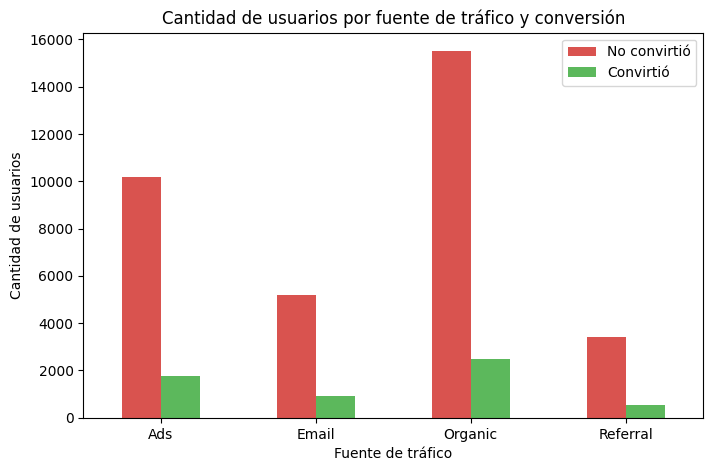

In [ ]:
conteo_fuente = pd.crosstab(df['traffic_source'], df['converted'])

conteo_fuente.plot(kind='bar', stacked=False, figsize=(8,5), color=['#d9534f', '#5cb85c'])
plt.title('Cantidad de usuarios por fuente de tráfico y conversión')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

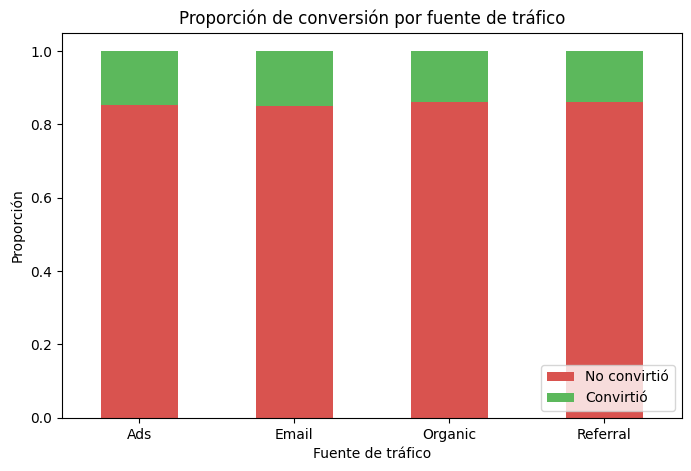

In [ ]:
# Proporción de usuarios que convirtieron y no convirtieron por fuente de tráfico
proporcion_fuente = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')

proporcion_fuente.plot(kind='bar', stacked=True, figsize=(8,5), color=['#d9534f', '#5cb85c'])
plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend(['No convirtió', 'Convirtió'], loc='lower right')
plt.show()

✍️ **Comentario**:

El gráfico de cantidades absolutas confirma que Organic es, por mucho, el canal que más tráfico y más conversiones aporta en términos brutos, seguido de Ads. Sin embargo, al observar las proporciones, se ve que las barras de conversión (en verde) tienen una altura muy similar entre los cuatro canales, lo cual es consistente con lo que arrojó la prueba Chi-cuadrado: hay una diferencia estadísticamente significativa, pero pequeña en magnitud. Ningún canal destaca de forma dramática sobre los demás en su capacidad de convertir usuarios.

### Relación entre el tipo de usuario y la conversión

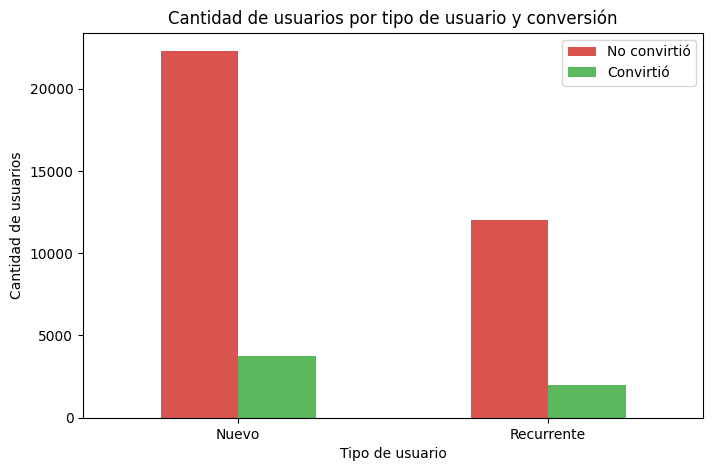

In [ ]:
# Cantidad absoluta de usuarios que convirtieron y no convirtieron por tipo de usuario
conteo_usuario = pd.crosstab(df['user_type'], df['converted'])

conteo_usuario.plot(kind='bar', stacked=False, figsize=(8,5), color=['#d9534f', '#5cb85c'])
plt.title('Cantidad de usuarios por tipo de usuario y conversión')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

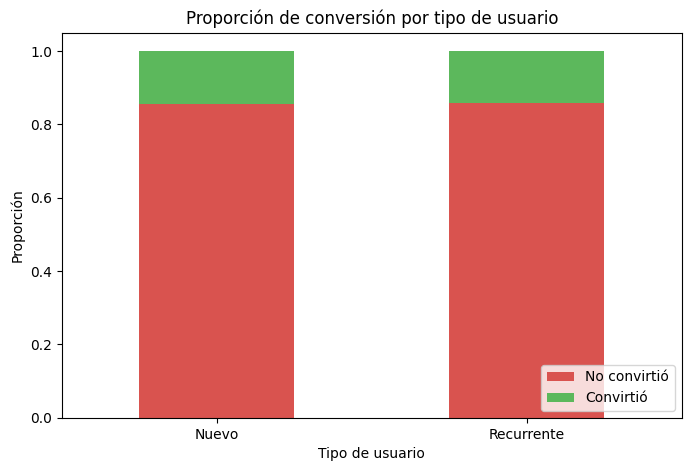

In [ ]:
# Proporción de usuarios que convirtieron y no convirtieron por tipo de usuario
proporcion_usuario = pd.crosstab(df['user_type'], df['converted'], normalize='index')

proporcion_usuario.plot(kind='bar', stacked=True, figsize=(8,5), color=['#d9534f', '#5cb85c'])
plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend(['No convirtió', 'Convirtió'], loc='lower right')
plt.show()

✍️ **Comentario**:

Tanto en cantidades absolutas como en proporciones, usuarios nuevos y recurrentes se comportan de manera prácticamente idéntica: hay más usuarios nuevos en el dataset (por eso las barras absolutas son más altas para ese grupo), pero la proporción que convierte es casi la misma en ambos casos. Esto refuerza visualmente lo que ya habíamos concluido con la prueba estadística: el tipo de usuario no es un factor que influya en la conversión dentro de este experimento.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- Observación 1: El gasto promedio de los usuarios que convirtieron con la página B fue de $68.75, frente a $61.09 en la página A.
  
-Observación 2: La prueba estadística (Welch's t-test) confirmó que esta diferencia es significativa (p-value ≈ 0), es decir, no se debe al azar.

- **Interpretación:**

Los usuarios que llegan a comprar a través de la página B no solo son más numerosos, sino que también gastan más una vez que deciden convertir. Esto se traduce en un mayor valor económico por cliente para la versión B.

**Tasa de conversión:**

-Observación 1: La página B logró una tasa de conversión de 15.96%, superior al 12.57% de la página A.

-Observación 2: La prueba de proporciones (z-test) confirmó que esta diferencia de casi 3.4 puntos porcentuales es estadísticamente significativa (p-value ≈ 0).

- **Interpretación:**

La página B convierte proporcionalmente más usuarios que la página A, aproximadamente un 27% más en términos relativos. Combinado con el hallazgo anterior, la página B se perfila como la versión ganadora del experimento tanto en volumen de conversiones como en valor generado por cada una.

#### 📊 **Segmentación por fuente de tráfico**

Observación: Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (Chi-cuadrado, p-value = 0.0341), aunque la diferencia práctica entre canales es pequeña: las tasas van de 13.79% (Organic) a 14.99% (Email), un rango de apenas 1.2 puntos porcentuales. En volumen absoluto, Organic sigue siendo el canal que más conversiones aporta, simplemente porque también es el que más tráfico recibe.

- **Interpretación:**

El canal de adquisición influye levemente en la conversión, pero no es un factor decisivo. Email y Ads muestran una eficiencia ligeramente mayor por usuario, lo que podría considerarse al momento de distribuir el presupuesto de marketing, sin esperar un impacto dramático solo por este ajuste.

#### 📊 **Segmentación por tipo de usuario**

Observación: No se encontró una asociación estadísticamente significativa entre el tipo de usuario y la conversión (Chi-cuadrado, p-value = 0.4736). Las tasas de conversión son prácticamente iguales: 14.36% para usuarios nuevos y 14.09% para recurrentes.

- **Interpretación:**

El historial del usuario (nuevo o recurrente) no es un factor que explique diferencias en la conversión dentro de este experimento. Esto sugiere que ambas versiones de la página funcionan de manera consistente sin importar si el usuario ya conocía el sitio o no.

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

#### 💡 **Recomendaciones de negocio:**

-Implementar la página B como versión definitiva de la landing page. Genera una tasa de conversión superior (15.96% vs 12.57%) y un mayor gasto promedio por usuario convertido ($68.75 vs $61.09), ambos resultados respaldados por pruebas estadísticas con alta significancia. Esto se traduce en un mayor retorno económico por visitante para el negocio.

-No es necesario personalizar la estrategia por tipo de usuario (nuevo vs. recurrente), ya que ambos segmentos responden de forma prácticamente idéntica a las versiones de la página. Los recursos de personalización pueden enfocarse en otras variables con mayor potencial de impacto.

-Mantener una inversión diversificada en canales de tráfico, priorizando ligeramente Email y Ads sobre Organic y Referral, dado que muestran una eficiencia de conversión levemente superior. Sin embargo, dado que la diferencia entre canales es modesta, no se recomienda una reasignación drástica de presupuesto basada únicamente en este hallazgo.

-Monitorear el desempeño de la página B tras su implementación completa, idealmente con una ventana de observación similar (o mayor) a la del experimento actual, para confirmar que las mejoras se sostienen en el tiempo y no son un efecto temporal del periodo evaluado.